In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
input_dataset = "/content/drive/MyDrive/major"
output_dataset = "/content/drive/MyDrive/preprocessed"

img_size = 128

In [ ]:
if not os.path.exists(output_dataset):
    os.makedirs(output_dataset)

In [ ]:
for root, dirs, files in os.walk(input_dataset):

    relative_path = os.path.relpath(root, input_dataset)
    save_folder = os.path.join(output_dataset, relative_path)

    os.makedirs(save_folder, exist_ok=True)

    print("Processing folder:", root)

    for file in tqdm(files):

        if file.lower().endswith(('.png','.jpg','.jpeg')):

            img_path = os.path.join(root, file)

            try:
                img = cv2.imread(img_path)

                if img is None:
                    continue

                img = cv2.resize(img, (img_size, img_size))

                img = img / 255.0

                save_path = os.path.join(save_folder, file)

                cv2.imwrite(save_path, (img*255).astype("uint8"))

            except:
                pass

Processing folder: /content/drive/MyDrive/major


100%|██████████| 1/1 [00:00<00:00, 6250.83it/s]


Processing folder: /content/drive/MyDrive/major/test


0it [00:00, ?it/s]


Processing folder: /content/drive/MyDrive/major/test/earthquake


...

0it [00:00, ?it/s]


Processing folder: /content/drive/MyDrive/major/preprocessed/preprocessed/train/fire


100%|██████████| 1380/1380 [00:58<00:00, 23.66it/s]


Processing folder: /content/drive/MyDrive/major/preprocessed/preprocessed/nondisaster


100%|██████████| 867/867 [00:30<00:00, 28.09it/s]


In [ ]:
train_fire = "/content/drive/MyDrive/major/preprocessed/train/fire"
train_earthquake = "/content/drive/MyDrive/major/preprocessed/train/earthquake"
train_nondisaster = "/content/drive/MyDrive/major/preprocessed/nondisaster"

img_size = 128

In [ ]:
test_fire = "/content/drive/MyDrive/major/preprocessed/test/fire"
test_earthquake = "/content/drive/MyDrive/major/preprocessed/test/earthquake"
test_nondisaster = "/content/drive/MyDrive/major/preprocessed/test/nondisaster"

img_size = 128

In [ ]:
def load_images(folder, label, data, labels):

    for img_name in tqdm(os.listdir(folder)):

        img_path = os.path.join(folder, img_name)

        try:
            img = cv2.imread(img_path)
            img = cv2.resize(img,(img_size,img_size))

            data.append(img)
            labels.append(label)

        except:
            pass

In [ ]:
train_data = []
train_labels = []

load_images(train_fire,0,train_data,train_labels)
load_images(train_earthquake,1,train_data,train_labels)
load_images(train_nondisaster,2,train_data,train_labels)


100%|██████████| 867/867 [00:12<00:00, 71.78it/s] 


In [ ]:
X_train = np.array(train_data)/255.0
y_train = np.array(train_labels)

In [ ]:
test_data = []
test_labels = []

load_images(test_fire,0,test_data,test_labels)
load_images(test_earthquake,1,test_data,test_labels)
load_images(test_nondisaster,2,test_data,test_labels)

100%|██████████| 100/100 [00:01<00:00, 98.97it/s]


In [ ]:
X_test = np.array(test_data)/255.0
y_test = np.array(test_labels)

In [ ]:
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=17,
    batch_size=30,
    validation_data=(X_test,y_test)
)

Epoch 1/17
119/119 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.8785 - loss: 0.3256 - val_accuracy: 0.8944 - val_loss: 0.2891
Epoch 2/17
119/119 ━━━━━━━━━━━━━━━━━━━━ 140s 992ms/step - accuracy: 0.9032 - loss: 0.2699 - val_accuracy: 0.9100 - val_loss: 0.2868
Epoch 3/17
119/119 ━━━━━━━━━━━━━━━━━━━━ 117s 980ms/step - accuracy: 0.9105 - loss: 0.2315 - val_accuracy: 0.9422 - val_loss: 0.1937
Epoch 4/17
119/119 ━━━━━━━━━━━━━━━━━━━━ 140s 972ms/step - accuracy: 0.9337 - loss: 0.1808 - val_accuracy: 0.9367 - val_loss: 0.2293
Epoch 5/17
119/119 ━━━━━━━━━━━━━━━━━━━━ 117s 987ms/step - accuracy: 0.9358 - loss: 0.1512 - val_accuracy: 0.9189 - val_loss: 0.2880
Epoch 6/17
119/119 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.9567 - loss: 0.1189 - val_accuracy: 0.9578 - val_loss: 0.1540
Epoch 7/17
119/119 ━━━━━━━━━━━━━━━━━━━━ 139s 991ms/step - accuracy: 0.9698 - loss: 0.0959 - val_accuracy: 0.9333 - val_loss: 0.3259
Epoch 8/17
119/119 ━━━━━━━━━━━━━━━━━━━━ 117s 979ms/step - accuracy: 0.9712 - loss:

In [ ]:
loss,accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy:",accuracy)

29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 308ms/step - accuracy: 0.9613 - loss: 0.1744
Test Accuracy: 0.9566666483879089


In [ ]:
model.save("/content/drive/MyDrive/major/disaster_cnn_model.h5")

Prediction/Input

In [2]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/major/disaster_cnn_model.h5")

In [3]:
import cv2
import numpy as np

In [14]:
def predict_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img,(128,128))
    img = img/255.0
    img = np.expand_dims(img,axis=0)
    pred = model.predict(img)
    class_id = np.argmax(pred)
    classes = ["Fire","Earthquake","Non-Disaster"]
    print("Disaster Type:",classes[class_id])

In [15]:
predict_image("/content/drive/MyDrive/major/input/buildingfire_2016-07-24_23-27-59.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Disaster Type: Fire


Accuracy/Matrix

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 370ms/step - accuracy: 0.9613 - loss: 0.1744
Test Loss: 0.2377863973379135
Test Accuracy: 0.9566666483879089


In [ ]:
import numpy as np
predictions = model.predict(X_test)
y_pred = np.argmax(predictions, axis=1)

29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 287ms/step


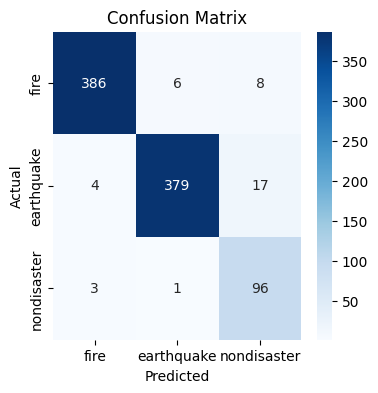

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
class_names = ["fire","earthquake","nondisaster"]
plt.figure(figsize=(4,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
        y_test,
        y_pred,
        target_names=["fire","earthquake","nondisaster"]
))

              precision    recall  f1-score   support

        fire       0.98      0.96      0.97       400
  earthquake       0.98      0.95      0.96       400
 nondisaster       0.79      0.96      0.87       100

    accuracy                           0.96       900
   macro avg       0.92      0.96      0.94       900
weighted avg       0.96      0.96      0.96       900



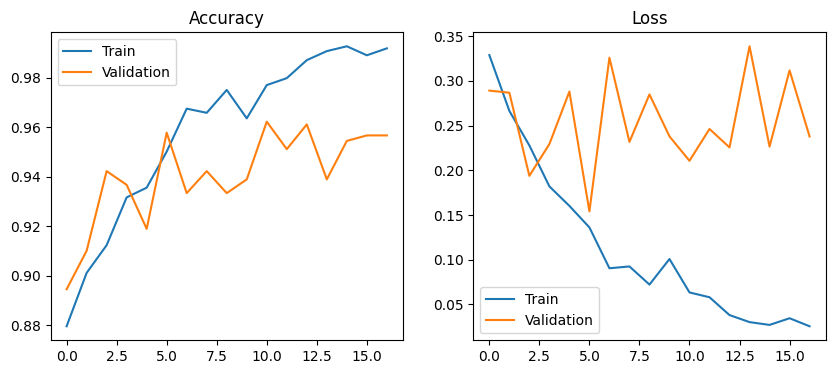

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Validation"])

plt.show()